# Import libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# load the dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape & Normalize

In [ ]:
x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255.0

# One hot encoding ( label encoding )

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train,num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Visualise (Optional)

In [ ]:
plt.imshow(x_train[0].reshape(28,28))
plt.title(f"Train label: {y_train[0]}")
plt.show()

# BUILD CNN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Create model

In [ ]:
# Input shape: (28, 28, 1)
model = Sequential()

# First layer - Convolutional 32 filters, 3x3 with stride 1 and padding = 'same'
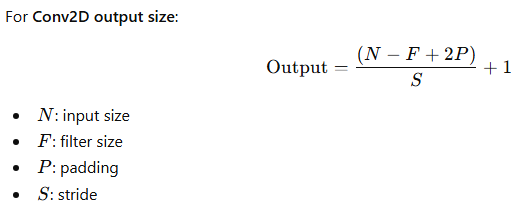
```
# -------------------------------
# Conv Layer 1
# -------------------------------
# Input: (28, 28, 1)
# Filters = 32, Kernel = 3x3, Padding = 'same', Stride = 1
# SAME padding → output size remains same
# Output: (28, 28, 32)
```


In [ ]:
model.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=(28,28,1)))

# Maxpooling layer wtih 2x2 size

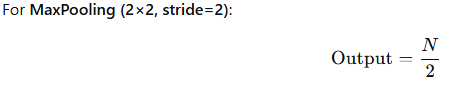
```
# -------------------------------
# MaxPooling Layer 1
# -------------------------------
# Input: (28, 28, 32)
# Pool size = (2,2), stride = 2
# Output: (14, 14, 32)
```


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layers with 64 filters, 3x3 and same padding and strides = 1

```
# -------------------------------
# Conv Layer 2
# -------------------------------
# Input: (14, 14, 32)
# Filters = 64, Kernel = 3x3, Padding = 'same'
# Output: (14, 14, 64)

# -------------------------------
# MaxPooling Layer 2
# -------------------------------
# Input: (14, 14, 64)
# Output: (7, 7, 64)
```

In [ ]:
model.add(Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Dropout for Regularization (Drop 25% neurons)
```
# -------------------------------
# Dropout (no change in shape)
# -------------------------------
# Output: (7, 7, 64)
```

In [ ]:
model.add(Dropout(0.25))

# Flatten before dense layer
```

# -------------------------------
# Flatten Layer
# -------------------------------
# Input: (7, 7, 64)
# Flatten → 7 * 7 * 64 = 3136
# Output: (3136,)
```

In [ ]:
model.add(Flatten())

# Add dense layer
```
# -------------------------------
# Dense Layer 1
# -------------------------------
# Input: 3136 neurons
# Output: 128 neurons
```

In [ ]:
model.add(Dense(128, activation='relu'))

# Dropout for Regularization (Drop 25% neurons)
```
# -------------------------------
# Dropout (no change)
# -------------------------------
# Output: (128,)
```

In [ ]:
model.add(Dropout(0.5))

# Add dense layer
```
# -------------------------------
# Output Layer
# -------------------------------
# Input: 128
# Output: 10 (digits 0–9)
```

In [ ]:
model.add(Dense(10, activation='softmax'))

# Compile the model

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model

In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size = 128, validation_data=(x_test, y_test), verbose=1)

# Evaluate on test data

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Predict on a test image

In [ ]:
index = 0  # Change this to try different test images
test_image = x_test[index]  # Shape: (28, 28)
prediction = model.predict(np.expand_dims(test_image, axis=0))  # Add batch dim: (1, 28, 28)

# Output prediction

In [ ]:
predicted_label = np.argmax(prediction)
print("Predicted label:", predicted_label)
print("True label:", y_test[index])

# Visualization

In [ ]:
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap='gray')
plt.title(f"Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(10), prediction[0])
plt.title(f"Predicted Probabilities")
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.xticks(range(10))
plt.show()

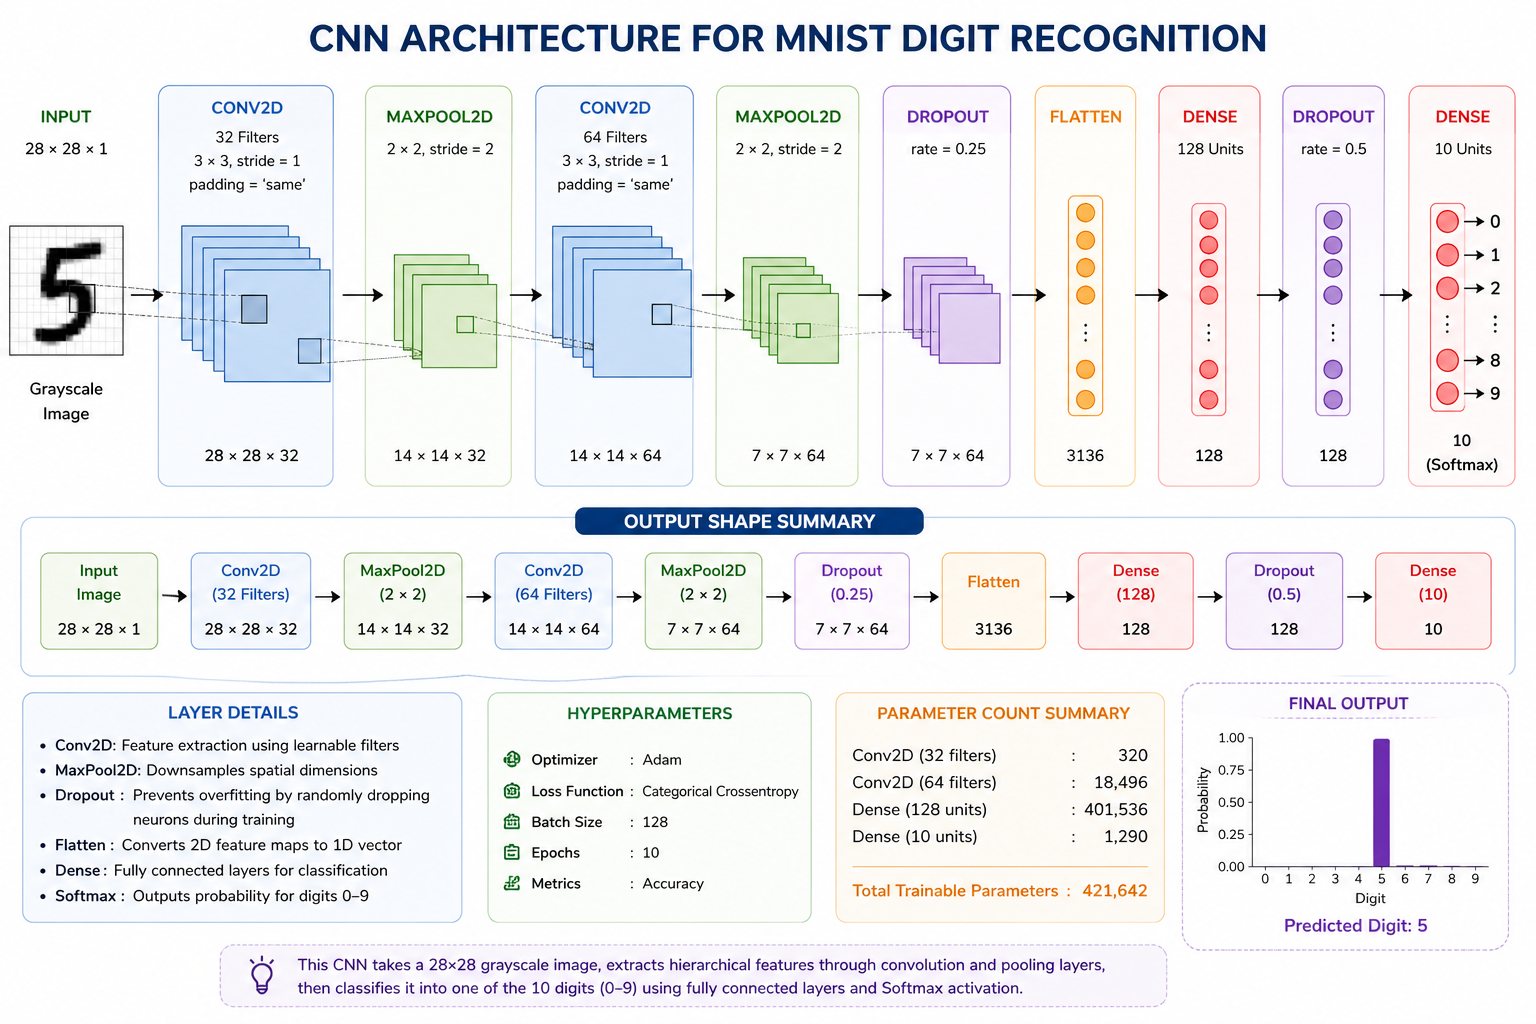